# Image Embedding and Correlations with NAcc Activity
Authors: Brenden Eum & Tom Henning (2024)

## Pre-Processing.

Libraries.

In [1]:
# For images.
from PIL import Image
# For data analysis.
import numpy as np
# For machine learning.
import torch
from torchvision import transforms, models
# For visualization.
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
# Assuming you're using a ResNet model
from torchvision.models import resnet50
import torchvision.transforms as transforms

Load and clean the image before preprocessing it for pre-trained models.

In [2]:
png_img = Image.open("../../experiment/stimuli/Stimuli/TRI_car_imgs/2021_Toyota_RAV4_XLE_SilverSkyMetallic_3-4angle_US.png")
img = Image.new("RGB", png_img.size, (512, 512, 512)) # Convert to RGB.
img.paste(png_img, mask=png_img.split()[3])  # Use the alpha channel as a mask. Transparent -> White.
img = img.resize((512,512)) # Resize to a fixed input size for pre-trained models.

Normalize the pixel values. 

Normalize the image using mean and SD values specific to the pre-trained models. For ResNet, use ImageNet's values.

In [3]:
preprocess = transforms.Compose([
    transforms.ToTensor(), # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_tensor = preprocess(img).unsqueeze(0) # Add batch dimension

## Map pre-processed image to embedding space.

Set up the model.

Let's use a pre-trained model for classification, like ResNet50, then remove the classification layer to look at the embedding space. First, we need to set up the model without the classification layer.

In [4]:
# Load pre-trained ResNet50.
model = models.resnet50(pretrained=True)
# Remove the final classification layer to get embeddings.
model = torch.nn.Sequential(*list(model.children())[:-1])
# Set the model to evaulation mode.
model.eval()

/Users/brenden/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/brenden/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


Get embedding.

Now pass the preprocessed image through the model to obtain its feature embedding.

In [5]:
with torch.no_grad():
    embedding = model(img_tensor).squeeze()
embedding

tensor([0.1525, 0.0605, 0.1651,  ..., 0.0568, 0.0939, 0.2047])

## Analyze the embedding.

Get the values for every embedding feature. ResNet outputs 2048-dimensional embeddings.

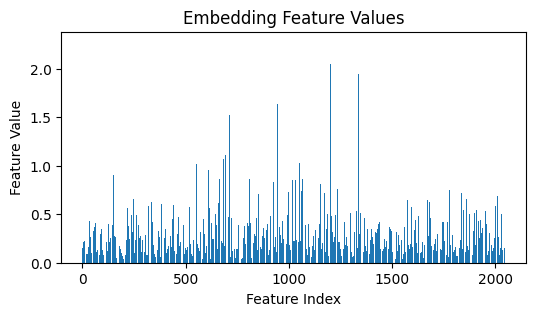

In [6]:
# Assuming `embedding` is a PyTorch tensor or NumPy array
embedding_array = embedding.numpy() if hasattr(embedding, "numpy") else embedding

# Create a bar plot of the embedding values
plt.figure(figsize=(6, 3))
plt.bar(range(len(embedding_array)), embedding_array)
plt.xlabel("Feature Index")
plt.ylabel("Feature Value")
plt.title("Embedding Feature Values")
plt.show()

# Tom notes

Take this embedding vector, sort by "most variance explained" (might need PCA for this). 10,000 cars ratings. 

Look for an image generator (from an embedding space), not just an image classifier. We should be able to sort embedding dimensions in order of "variance explained" using a regression or something -> See if any of those important embedding dimesions correlates with NAcc activity... which may also give some explanation for aesthetic preference. From there, we can do the Sendhil extreme generator method to get some interpretability. 

Buzzfeed's top 10 most important features.

In [7]:
top_features = np.argsort(embedding_array)[-10:]  # Top 10 feature indices
print("Top 10 feature indices:", top_features)
print("Top 10 feature values:", embedding_array[top_features])

Top 10 feature indices: [ 712 1231  945 1254 1337 1302 1201 2018 1839 1532]
Top 10 feature values: [1.5208699 1.6278135 1.6369137 1.6525506 1.9392997 1.9826497 2.0512857
 2.2157435 2.2547467 2.266608 ]


Aggregate: Visualize the parts of the original image that contribute the most to the last layer before classification in ResNet50.

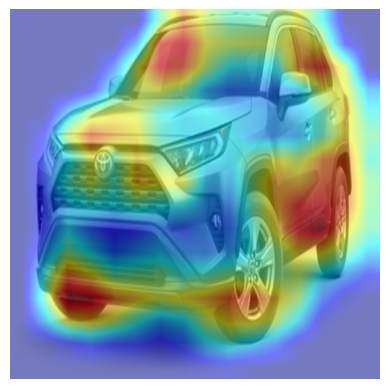

In [8]:
# Load the pre-trained ResNet50 model again, so you can access the target layer later.
model = resnet50(pretrained=True)
model.eval()  # Set the model to evaluation mode

# Define the target layer (use the name of the layer explicitly for compatibility)
target_layer = model.layer4[-1]  # Last convolutional block in ResNet50

# Convert the image tensor back to numpy (for visualization)
original_image = img_tensor.squeeze(0).permute(1, 2, 0).numpy()
original_image = (original_image - original_image.min()) / (original_image.max() - original_image.min())  # Normalize for visualization

# Initialize Grad-CAM
cam = GradCAM(model=model, target_layers=[target_layer])

# Generate Grad-CAM heatmap
grayscale_cam = cam(input_tensor=img_tensor)[0]  # Extract the heatmap for the first (and only) image

# Overlay Grad-CAM heatmap on the original image
visualization = show_cam_on_image(original_image, grayscale_cam, use_rgb=True)

# Display the result
plt.imshow(visualization)
plt.axis('off')
plt.show()